# **Please make your own copy to edit the notebook** 📝

# **Sentiment Analysis with an RNN 🍿**

You will implement a recurrent neural network (RNN) that performs sentiment analysis (positive = 1 and negative = 0) of movie reviews. This notebook has been created with the help of previous IDL TAs 📣 and [this tutorial 🔥](https://colab.research.google.com/github/agungsantoso/deep-learning-v2-pytorch/blob/master/sentiment-rnn/Sentiment_RNN_Exercise.ipynb).

<img src="https://github.com/agungsantoso/deep-learning-v2-pytorch/blob/master/sentiment-rnn/assets/reviews_ex.png?raw=1" width=30%>

## **Workflow**


<img src="https://drive.google.com/uc?id=16rbcj6jDhQNJ7AB7JyX4LD6rso3uQYjc" width=85%>


### **Network Architecture**

> 1️⃣. First, encode the words - pass in words to an embedding layer. We will use PyTorch's embedding layer (more on it in HW4).

> 2️⃣. Next, pass the word embeddings into the hidden layer. We will use PyTorch's LSTM which internally implements repeating the same LSTM cell for each time step. LSTM will add recurrent connections to the network and give us the ability to include information about the sequence of words in the movie review data.

> 3️⃣. Finally, the LSTM outputs will go through a linear layer activated by the sigmoid activation function to give 2 logits (positive = 1 and negative = 0).

Note that we ONLY care about the logits for the very last time step; we can ignore the rest.

We'll calculate the loss by comparing the logits at the last time step and the training label (pos or neg).

# **Imports**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from string import punctuation
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

# **Load in and visualize the data**

In [ ]:
!mkdir data
!wget -c https://github.com/agungsantoso/deep-learning-v2-pytorch/raw/master/sentiment-rnn/data/labels.txt
!wget -c https://github.com/agungsantoso/deep-learning-v2-pytorch/raw/master/sentiment-rnn/data/reviews.txt
!mv *.txt data/

--2026-02-27 13:29:36--  https://github.com/agungsantoso/deep-learning-v2-pytorch/raw/master/sentiment-rnn/data/labels.txt
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/agungsantoso/deep-learning-v2-pytorch/master/sentiment-rnn/data/labels.txt [following]
--2026-02-27 13:29:37--  https://raw.githubusercontent.com/agungsantoso/deep-learning-v2-pytorch/master/sentiment-rnn/data/labels.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 225000 (220K) [text/plain]
Saving to: ‘labels.txt’

labels.txt          100%[===================>] 219.73K  --.-KB/s    in 0.02s   

2026-02-27 13:29:37 (8.89 MB/

In [ ]:
# read data from text files
with open('data/reviews.txt', 'r') as f:
    reviews = f.read()
with open('data/labels.txt', 'r') as f:
    labels = f.read()

In [ ]:
# reviews is a string variable having the contents of the entire reviews.txt file
# labels is a string variable having the contents of the entire labels.txt file
print(reviews[:2000])
print(labels[:20])

bromwell high is a cartoon comedy . it ran at the same time as some other programs about school life  such as  teachers  . my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers  . the scramble to survive financially  the insightful students who can see right through their pathetic teachers  pomp  the pettiness of the whole situation  all remind me of the schools i knew and their students . when i saw the episode in which a student repeatedly tried to burn down the school  i immediately recalled . . . . . . . . . at . . . . . . . . . . high . a classic line inspector i  m here to sack one of your teachers . student welcome to bromwell high . i expect that many adults of my age think that bromwell high is far fetched . what a pity that it isn  t   
story of a man who has unnatural feelings for a pig . starts out with a opening scene that is a terrific example of absurd comedy . a formal orchestra audience is turn

# **Data pre-processing (Checkpoint \#1)**

We need to implement some data cleaning and processing steps before trainng and testing. Here's the plan:

1. Convert all reviews to lower case and remove special characters like
punctuations.
1. Separate the large string of all reviews and the labels into individual entries by the delimiter `\n`.
1. Convert the text reviews into integers. For this, we will first create a vocabulary of all words.
1. Replace words in reviews by their index in the vocabulary.
1. Encode labels as integers. Positive becomes 1 and negative becomes 0.
1. Remove 0 length and truncate too long reviews.

In [ ]:
print(punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [ ]:
# Step 1: Convert all reviews to lower case and remove special characters like punctuations.
reviews =#TODO: Convert to lowercase
all_text = #TODO: Remove special characters (hint: join)

In [ ]:
# Step 2: Separate the large string of all reviews into individual reviews and the same for labels.
reviews_split = #TODO
labels_split = #TODO

In [ ]:
# Step 3: Create a vocabulary of all words.
all_text = #TODO: join
words = #TODO: split on whitespaces

# Create vocabulary in decreasing order of word frequency in the corpus. Not necessary to obey this order though.
counts = #TODO: dict (look into imports)
vocab = #TODO: find unique words (careful sort)
vocab_to_int = #TODO: enumerate (encode) words

In [ ]:
print('Unique words: ', len((vocab_to_int)))

Unique words:  74072


In [ ]:
# Step 4: Replace words in reviews by their index in the vocabulary.
reviews_ints = []
for review in reviews_split:
  #TODO: list of int encoding for each word in each review

In [ ]:
# Notice that after encoding, each review in reviews_ints is a list of integers corresponding to the words in the review.
# Run this cell to see a few examples.

for ind in range(3):
  print ("Text review: "+reviews_split[ind]) # add the reviews text
  print ("Encoded review: "+str(reviews_ints[ind]) ) # add the encoded text
  print ("=============================")

Text review: bromwell high is a cartoon comedy  it ran at the same time as some other programs about school life  such as  teachers   my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers   the scramble to survive financially  the insightful students who can see right through their pathetic teachers  pomp  the pettiness of the whole situation  all remind me of the schools i knew and their students  when i saw the episode in which a student repeatedly tried to burn down the school  i immediately recalled          at           high  a classic line inspector i  m here to sack one of your teachers  student welcome to bromwell high  i expect that many adults of my age think that bromwell high is far fetched  what a pity that it isn  t   
Encoded review: [21025, 308, 6, 3, 1050, 207, 8, 2138, 32, 1, 171, 57, 15, 49, 81, 5785, 44, 382, 110, 140, 15, 5194, 60, 154, 9, 1, 4975, 5852, 475, 71, 5, 260, 12, 21025, 308, 13,

In [ ]:
# Step 5: Encode labels as integers. Positive becomes 1 and negative becomes 0.
encoded_labels = np.array([1 if label == 'positive' else 0 for label in labels_split])#TODO: list

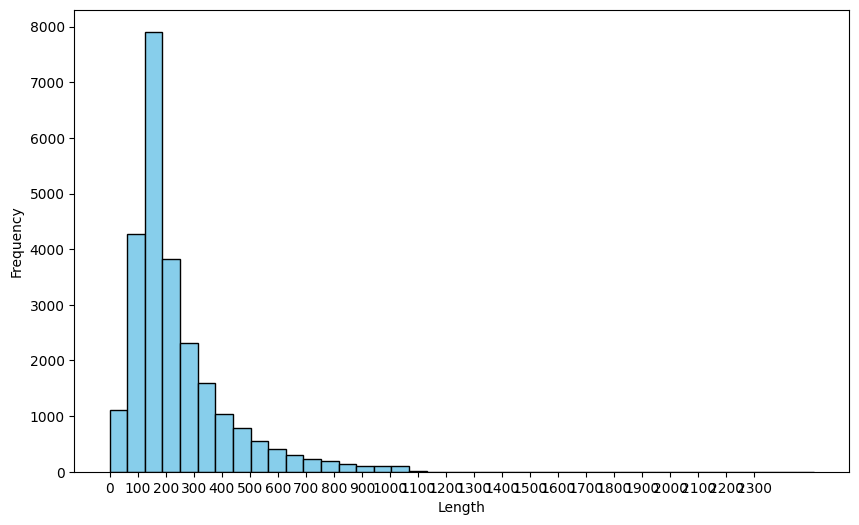

In [ ]:
# Step 6: Remove 0 length and truncate too long reviews. ** No Change **

# First let's analyze the distribution of review lengths.
lengths = [len(review) for review in reviews_ints]
fig = plt.figure(figsize=[10,6])
plt.hist(lengths, bins=40, color='skyblue', edgecolor='black')
plt.xticks(range(0,2400,100))
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.show()

From the above historgram, 200 words looks like a good cutoff to truncate reviews at. Typically movie reviews would signal positive or negative in the first 200 words. Also a large majority of reviews seem to be under 200 words long.

In [ ]:
# Remove reviews with 0 length.
non_zero_idx =  #TODO
print ("There are "+str(len(reviews_ints)-len(non_zero_idx))+ " reviews with 0 length. Removing them.")

reviews_ints = #TODO
encoded_labels = #TODO

There are 1 reviews with 0 length. Removing them.


In [ ]:
# Truncating all reviews to first 200 words.
MAX_LEN = 200
reviews_ints = #TODO

# **Dataset and dataloader (Checkpoint \#2)**
We will split the dataset into train, val, and test. We will use 80% for train and 10% each for val and test.

We will then create a dataset class to be used across the 3 splits. Note that we have access to test data labels so we can use the same dataset class (unlike the homeworks).

In [ ]:
## split data into training, validation, and test data (reviews and labels, x and y)
split_idx = int(len(reviews_ints)*0.8)
train_x, remaining_x = reviews_ints[:split_idx], reviews_ints[split_idx:]#TODO slice 🍕
train_y, remaining_y = encoded_labels[:split_idx], encoded_labels[split_idx:]#TODO

test_idx = int(len(remaining_x)*0.5)
val_x, test_x = remaining_x[:test_idx], remaining_x[test_idx:]#TODO
val_y, test_y = remaining_y[:test_idx], remaining_y[test_idx:]#TODO

## print out the shapes of your resultant data
print("Number of reviews:")
print("Train set: \t\t{}".format(len(train_x)),
      "\nValidation set: \t{}".format(len(val_x)),
      "\nTest set: \t\t{}".format(len(test_x)))

Number of reviews:
Train set: 		20000 
Validation set: 	2500 
Test set: 		2500


### **Padding**

Our network takes batches of inputs. Suppose the batch size is 64. To be able to process this batch at once, all 64 reviews should have the same length. If batch size is the first dimension of the input tensor, then the sequence length should be second dimension - which means that the sequence length should be the same for all the sequences in the batch. We take care of reviews of different lengths by padding all reviews shorter than the longest review in the batch with zeros. That is why we started our vocabulary indexing from 1. 0 would be the index of the pad token.

While this can be implemented manually, we will use PyTorch's `pad_sequence` in the collate method of the dataset class. The collate method performs some actions on a list of items returned from `__get_item__` method to be able to make these items into a batch that is fed into the dataloader.

Before writing the dataset class, let's look at an example of the pad_sequence function.

In [ ]:
# Let's create a list of few reviews and look at their lengths. Observe that these are all different.
list_of_reviews = [torch.tensor(review) for review in train_x[:5]]
for review in list_of_reviews:
    print(review.shape)

torch.Size([140])
torch.Size([114])
torch.Size([200])
torch.Size([200])
torch.Size([150])


In [ ]:
# Assuming this list is a batch, i.e., batch size of 5.
# Return tensor of shape B X T where B is batch_size and T is max sequence length.
padded_batch = pad_sequence(list_of_reviews, batch_first=True)#TODO

In [ ]:
print (padded_batch.shape)

torch.Size([5, 200])


In [ ]:
# Let's look at the first sequence which was 140 words long originally. Observe the 0 padding after the 140 words.
print (padded_batch[0])

tensor([21025,   308,     6,     3,  1050,   207,     8,  2138,    32,     1,
          171,    57,    15,    49,    81,  5785,    44,   382,   110,   140,
           15,  5194,    60,   154,     9,     1,  4975,  5852,   475,    71,
            5,   260,    12, 21025,   308,    13,  1978,     6,    74,  2395,
            5,   613,    73,     6,  5194,     1, 24103,     5,  1983, 10166,
            1,  5786,  1499,    36,    51,    66,   204,   145,    67,  1199,
         5194, 19869,     1, 37442,     4,     1,   221,   883,    31,  2988,
           71,     4,     1,  5787,    10,   686,     2,    67,  1499,    54,
           10,   216,     1,   383,     9,    62,     3,  1406,  3686,   783,
            5,  3483,   180,     1,   382,    10,  1212, 13583,    32,   308,
            3,   349,   341,  2913,    10,   143,   127,     5,  7690,    30,
            4,   129,  5194,  1406,  2326,     5, 21025,   308,    10,   528,
           12,   109,  1448,     4,    60,   543,   102,    12, 

### **The Dataset class**
Pay attention to the code. It will be useful in your homeworks as well.

In [ ]:
class ReviewsDataset(Dataset):

    def __init__(self, reviews, labels):

        '''
        Initializes the dataset.

        INPUTS:
        reviews : List of integer encoded reviews.
        labels: List if integer encoded labels.
        '''

        self.reviews = reviews
        self.labels = labels

        assert len(self.reviews) == len(self.labels)

        self.length = len(self.reviews)

    def __len__(self):

        return self.length

    def __getitem__(self, ind):

        review = self.reviews[ind]
        label = self.labels[ind]
        return torch.tensor(review), torch.tensor(label)

    def collate_fn(self,batch):

        batch_reviews, batch_labels  = zip(*batch)

        batch_reviews_pad = pad_sequence(batch_reviews, batch_first=True)

        return batch_reviews_pad, torch.tensor(batch_labels)


### **Creating the Datasets and Dataloaders**

In [ ]:
BATCH_SIZE = 256

# datasets
train_data = ReviewsDataset(train_x, train_y)#TODO
valid_data = ReviewsDataset(val_x, val_y)#TODO
test_data = ReviewsDataset(test_x, test_y)#TODO

# dataloaders
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE, collate_fn=train_data.collate_fn)#TODO
valid_loader = DataLoader(valid_data, shuffle=False, batch_size=BATCH_SIZE, collate_fn=valid_data.collate_fn)#TODO
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE, collate_fn=test_data.collate_fn)#TODO

print("Batch size: ", BATCH_SIZE)
print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Val dataset samples = {}, batches = {}".format(valid_data.__len__(), len(valid_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size:  256
Train dataset samples = 20000, batches = 79
Val dataset samples = 2500, batches = 10
Test dataset samples = 2500, batches = 10


In [ ]:
# obtain one batch of training data
for sample_x, sample_y in train_loader:
    print('Sample input size: ', sample_x.size()) # batch_size, seq_length
    print('Sample input: \n', sample_x)
    print()
    print('Sample label size: ', sample_y.size()) # batch_size
    print('Sample label: \n', sample_y)
    break

Sample input size:  torch.Size([256, 200])
Sample input: 
 tensor([[   11,    20,   374,  ...,  1945,    34,  2058],
        [   10,    43,    89,  ...,     0,     0,     0],
        [   10,   371,   148,  ...,  8018,    38,  1517],
        ...,
        [   60,    84,   578,  ...,    48,   563,     5],
        [ 7447, 48098,     9,  ...,     0,     0,     0],
        [   51,    10,   200,  ...,     0,     0,     0]])

Sample label size:  torch.Size([256])
Sample label: 
 tensor([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 

# **Model Construction: LSTM Network with PyTorch (Checkpoint #3)**

The layers are as follows:
1. The [Embedding Layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html) that converts our word tokens (integers) into embeddings of a specific size. This is a feature extraction step for each word.
2. We will use a bidirectional [LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html) defined by a hidden_state size and number of LSTM layers.
3. The fully-connected output layer that maps the LSTM layer outputs to a desired output_size and get the logits. (You can experiment with this part like having a small MLP instead of a single linear layer.)

<img src="https://drive.google.com/uc?id=1j2RjVWC7TvyPXNityJCUjFtDzXLtbtei">


Most of the time, an RNN will have better performance with more hidden LSTM layers. Adding more layers allows the network to learn really complex relationships, but at the cost higher memory requirements.

In [ ]:
# First checking if GPU is available
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

In [ ]:
class SentimentNetwork(nn.Module):
    """
    The RNN model that will be used to perform Sentiment analysis.
    """

    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        """
        Initialize the model by setting up the layers.
        """
        super(SentimentNetwork, self).__init__()

        self.output_size = #TODO
        self.n_layers = #TODO
        self.hidden_dim = #TODO

        # embedding and LSTM layers
        self.embedding = #TODO
        self.lstm = #TODO

        # linear
        self.fc = #TODO: output of birectional LSTM has a vector for each direction. rethink input dim for the linear layer

    def forward(self, x):
        """
        Perform a forward pass of our model on some input and hidden state.
        """

        # embeddings and lstm_out
        embeds = #TODO
        lstm_out, _ =  #TODO

        # fully connected layer
        out = #TODO

        # return output of the last time step
        return NotImplemented


### **Instantiate the network**

Here, we'll instantiate the network and set some hyperparameters.

* `vocab_size`: Size of our vocabulary or the range of values for our input, word tokens.
* `output_size`: Size of our desired output; the number of class scores we want to output (pos/neg).
* `embedding_dim`: Number of columns in the embedding lookup table; size of our embeddings.
* `hidden_dim`: Number of units in the hidden layers of our LSTM cells. Usually larger is better performance wise. Common values are 128, 256, 512, etc.
* `n_layers`: Number of LSTM layers in the network. Typically between 1-3


In [ ]:
# Instantiate the model w/ hyperparams
vocab_size = len(vocab_to_int) + 1 # +1 for zero padding + our word tokens
output_size = 2
embedding_dim = 64
hidden_dim = 256
n_layers = 3
drop_prob = 0.4

model = #TODO

print(model)

# **Training the Network (Checkpoint \#4)**

Here, we give functions to train and validate your model. These are similar to what you have seen in homeworks so far.

In [ ]:
# hyperparameters, loss, and optimization functions
lr = 0.001
weight_decay = 1e-4
epochs = 20

criterion = #TODO
optimizer = #TODO
scheduler = #TODO
scaler = torch.amp.GradScaler()

In [ ]:
def train_model(model, train_loader, criterion, optimizer):

    model.train()
    batch_bar = tqdm(total=len(train_loader), dynamic_ncols=True, leave=False, position=0, desc='Train')

    total_loss = 0.0
    num_correct = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()

        x, y = data
        x, y = x.to(device), y.to(device)

        with torch.cuda.amp.autocast():
          logits = model(x)
          loss = criterion(logits, y)

        total_loss += float(loss.item())
        num_correct += int((torch.argmax(logits, axis=1) == y).sum())

        batch_bar.set_postfix(
            loss="{:.04f}".format(float(total_loss / (i + 1))),
            acc= "{:.04f}%".format(100 * num_correct / (BATCH_SIZE*(i + 1))),
            lr="{:.06f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        del x, y, logits, loss
        torch.cuda.empty_cache()

    batch_bar.close()

    acc = 100 * num_correct / (BATCH_SIZE* len(train_loader))

    return acc, total_loss / len(train_loader)


def validate_model(model, valid_loader, criterion):

    model.eval()
    batch_bar = tqdm(total=len(valid_loader), dynamic_ncols=True, position=0, leave=False, desc='Val')

    total_loss = 0.0
    num_correct = 0

    for i, data in enumerate(valid_loader):

        x, y = data
        x, y = x.to(device), y.to(device)

        with torch.inference_mode():
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += float(loss.item())
        num_correct += int((torch.argmax(logits, axis=1) == y).sum())

        batch_bar.set_postfix(loss="{:.04f}".format(float(total_loss / (i + 1))), acc= "{:.04f}%".format(100 * num_correct / (BATCH_SIZE*(i + 1))))

        batch_bar.update()

        del x, y, logits, loss
        torch.cuda.empty_cache()

    batch_bar.close()
    total_loss = total_loss/len(valid_loader)
    acc = 100 * num_correct / (BATCH_SIZE* len(valid_loader))
    return acc, total_loss

### **The Training loop**

In [ ]:
for epoch in range(epochs):
    print("\nEpoch: {}/{}".format(epoch + 1, epochs))

    curr_lr = float(optimizer.param_groups[0]['lr'])

    train_acc, train_loss = train_model(model, train_loader, criterion, optimizer)
    valid_acc, valid_loss = validate_model(model, valid_loader, criterion)
    scheduler.step()

    print("\tTrain Loss {:.04f}\t Learning Rate {:.07f}".format(train_loss, curr_lr))
    print("\tVal Acc {:.04f}\t Val Loss {:.04f}".format(valid_acc, valid_loss))

# **Testing the Network (Checkpoint \#5)**

Now, we'll see how our trained model performs on the `test_data` above by evaluating the average `loss` and `test_acc`.

In [ ]:
model.eval()
batch_bar = tqdm(total=len(test_loader), dynamic_ncols=True, position=0, leave=False, desc='Test')

total_loss = 0.0
num_correct = 0

for i, data in enumerate(test_loader):

    x, y = data
    x, y = x.to(device), y.to(device)

    with torch.inference_mode():
        logits = model(x)
        loss = criterion(logits, y)

    total_loss += float(loss.item())
    num_correct += int((torch.argmax(logits, axis=1) == y).sum())

    batch_bar.set_postfix(loss="{:.04f}".format(float(total_loss / (i + 1))), acc= "{:.04f}%".format(100 * num_correct / (BATCH_SIZE*(i + 1))))

    batch_bar.update()

    del x, y, logits, loss
    torch.cuda.empty_cache()

batch_bar.close()
total_loss = total_loss/len(test_loader)
test_acc = 100 * num_correct / (BATCH_SIZE* len(test_loader))

print("Test loss: {:.3f}".format(total_loss))
print("Test accuracy: {:.3f}".format(test_acc))


### **Inference on a test review**

You can change `test_review_neg` and `test_review_pos` to any text you want. Test if your model is doing what you expect!


In [ ]:
# negative test review
test_review_neg = 'The worst movie I have seen; acting was terrible and I want my money back. This movie had bad acting and the dialogue was slow.'


In [ ]:
def clean_and_encode_review(test_review):
    test_review = #TODO #convert to lower
    test_text = #TODO #Take out punction
    test_words = #TODO #split

    # Observe how even for one sample, we are creating a list of reviews.
    # This will act as a batch of size 1.
    test_ints = []
    #TODO

    return test_ints

# pre-process the review like we did for train and val
test_ints_neg = #TODO
print(test_ints_neg)

In [ ]:
# It is a single sample so we don't need to pad and can directly feed into the model.
out = #TODO
prediction = #TODO

print ("The review is classified as " + prediction)

In [ ]:
# positive test review
test_review_pos = 'This movie had the best acting and the dialogue was so good. I loved it.'

# pre-process the review like we did for train and val
test_ints_pos = #TODO
print(test_ints_pos)


In [ ]:
out = #TODO #same as previous cells
prediction = #TODO #same as previous cells

print ("The review is classified as " + prediction)